#Package Setup

In [1]:
# --------------------------------------------------
# NORTHSTAR URBAN MOBILITY PROJECT
# Notebook 2: SQL-Based Querying and Analysis in R
#
# Purpose: Execute structured queries on relational data,
#          generate business insights, and prepare outputs
#          for reporting and visualization.
# --------------------------------------------------

# Install and load required packages
install.packages(c("sqldf", "DBI", "RSQLite", "dplyr", "ggplot2"), quiet = TRUE)

library(sqldf)      # SQL queries on data frames
library(DBI)        # Database interface
library(RSQLite)    # SQLite database engine
library(dplyr)      # Data manipulation
library(ggplot2)    # Visualization

print("All required R packages have been loaded successfully.")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "All required R packages have been loaded successfully."


#Data Import

In [2]:
# --------------------------------------------------
# Import Processed Datasets
#
# Note: Files must be the output from Notebook 1
# (northstar_ready folder)
# --------------------------------------------------

processed_items <- c("complaints", "deliveries", "orders", "vehicles",
                     "drivers", "customers", "incidents", "app_events", "hubs")

for (item in processed_items) {
  df_name <- paste0(item, "_ready")
  file_path <- paste0(item, "_ready.csv")

  if (file.exists(file_path)) {
    assign(df_name, read.csv(file_path, stringsAsFactors = FALSE))
    cat("Successfully imported:", df_name, "→", nrow(get(df_name)), "records\n")
  } else {
    cat("Warning: File not found -", file_path, "\n")
  }
}

print("Data import phase completed.")

Successfully imported: complaints_ready → 320 records
Successfully imported: deliveries_ready → 950 records
Successfully imported: orders_ready → 1250 records
Successfully imported: vehicles_ready → 120 records
Successfully imported: drivers_ready → 170 records
Successfully imported: customers_ready → 650 records
Successfully imported: incidents_ready → 280 records
Successfully imported: app_events_ready → 640 records
Successfully imported: hubs_ready → 8 records
[1] "Data import phase completed."


#SQLite Database Creation

In [3]:
# --------------------------------------------------
# Initialize SQLite Database
#
# All tables are loaded into an in-memory SQLite database
# for efficient SQL querying.
# --------------------------------------------------

conn <- dbConnect(RSQLite::SQLite(), "northstar_query.db")

# Get all data frames ending with _ready
ready_tables <- ls(pattern = "_ready$")

for (tbl in ready_tables) {
  df_object <- get(tbl)
  clean_table_name <- gsub("_ready", "", tbl)

  dbWriteTable(conn, clean_table_name, df_object, overwrite = TRUE, row.names = FALSE)
  cat("Table loaded into database:", clean_table_name, "\n")
}

print("SQLite database is now ready for analysis.")

Table loaded into database: app_events 
Table loaded into database: complaints 
Table loaded into database: customers 
Table loaded into database: deliveries 
Table loaded into database: drivers 
Table loaded into database: hubs 
Table loaded into database: incidents 
Table loaded into database: orders 
Table loaded into database: vehicles 
[1] "SQLite database is now ready for analysis."


#Core Business Queries

In [6]:
# --------------------------------------------------
# Core Business Intelligence Queries
# --------------------------------------------------

cat("=== Query A: High-Value Customer Analysis ===\n")
dbGetQuery(conn, "
  SELECT c.customer_id,
         COUNT(DISTINCT o.order_id) AS total_orders,
         ROUND(SUM(o.order_value), 2) AS total_spent,
         COUNT(comp.complaint_id) AS complaints
  FROM customers c
  JOIN orders o ON c.customer_id = o.customer_id
  LEFT JOIN complaints comp ON o.order_id = comp.order_id
  GROUP BY c.customer_id
  HAVING total_spent > 500
  ORDER BY total_spent DESC
  LIMIT 10
")

cat("\n=== Query B: Vehicle Utilization & Issues ===\n")
dbGetQuery(conn, "
  SELECT v.vehicle_id,
         v.vehicle_type,
         COUNT(DISTINCT d.delivery_id) AS deliveries_made,
         COUNT(i.incident_id) AS incidents,
         ROUND(AVG(v.battery_health_pct), 2) AS avg_battery_health
  FROM vehicles v
  LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, v.vehicle_type
  ORDER BY incidents DESC
  LIMIT 8
")

cat("\n=== Query C: Time-of-Day Performance ===\n")
dbGetQuery(conn, "
  SELECT
    CASE
      WHEN strftime('%H', d.dispatch_time) BETWEEN '06' AND '11' THEN 'Morning'
      WHEN strftime('%H', d.dispatch_time) BETWEEN '12' AND '17' THEN 'Afternoon'
      WHEN strftime('%H', d.dispatch_time) BETWEEN '18' AND '23' THEN 'Evening'
      ELSE 'Night'
    END AS shift,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) * 100, 2) AS ontime_percentage
  FROM deliveries d
  GROUP BY shift
  ORDER BY ontime_percentage DESC
")

cat("\n=== Query D: Driver Experience vs Performance ===\n")
dbGetQuery(conn, "
  SELECT
    d.years_experience,
    ROUND(AVG(d.driver_rating), 2) AS avg_rating,
    COUNT(c.complaint_id) AS total_complaints,
    COUNT(DISTINCT del.delivery_id) AS deliveries_completed
  FROM drivers d
  LEFT JOIN deliveries del ON d.driver_id = del.driver_id
  LEFT JOIN complaints c ON del.order_id = c.order_id
  GROUP BY d.years_experience
  ORDER BY d.years_experience
")

=== Query A: High-Value Customer Analysis ===


customer_id,total_orders,total_spent,complaints
<chr>,<int>,<dbl>,<int>
C0545,6,1433.51,3
C0622,6,732.93,2
C0157,4,720.04,2
C0343,7,685.78,1
C0372,6,669.11,3
C0013,5,659.26,1
C0172,4,625.45,3
C0558,4,605.85,1
C0289,4,601.81,0



=== Query B: Vehicle Utilization & Issues ===


vehicle_id,vehicle_type,deliveries_made,incidents,avg_battery_health
<chr>,<chr>,<int>,<int>,<dbl>
V047,EV,17,9,93.7
V108,Diesel,9,7,54.6
V030,CargoVan,15,6,78.0
V046,EV,10,6,95.8
V097,EV,8,6,92.1
V005,CargoVan,13,5,58.6
V009,CargoVan,9,5,68.8
V035,CargoVan,9,5,83.6



=== Query C: Time-of-Day Performance ===


shift,total_deliveries,ontime_percentage
<chr>,<int>,<dbl>
Night,258,67.83
Evening,241,64.73
Afternoon,219,63.93
Morning,232,62.50



=== Query D: Driver Experience vs Performance ===


years_experience,avg_rating,total_complaints,deliveries_completed
<int>,<dbl>,<int>,<int>
1,4.26,11,42
2,4.34,12,62
3,4.13,13,51
4,3.95,19,76
5,3.89,15,52
6,4.19,12,53
7,4.27,11,58
8,3.87,16,79
9,4.15,13,58


#Visualizations

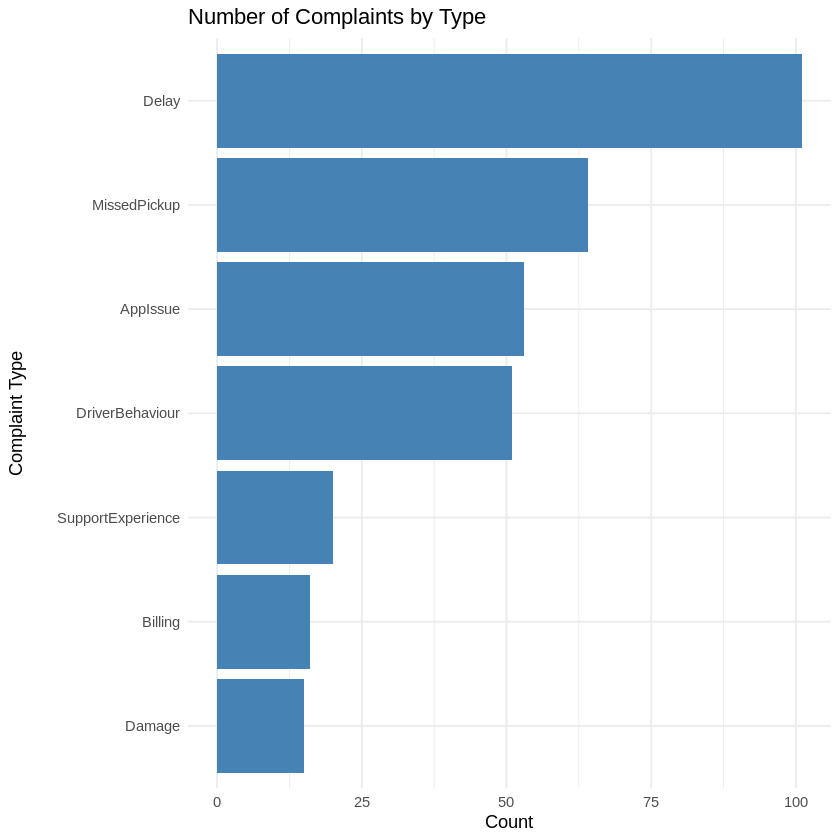

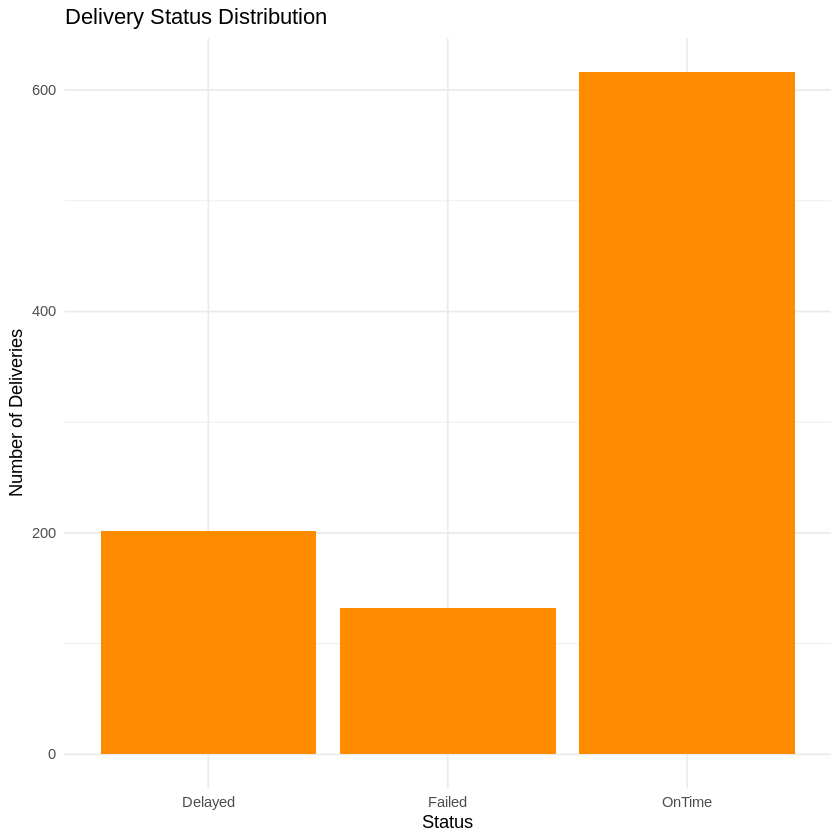

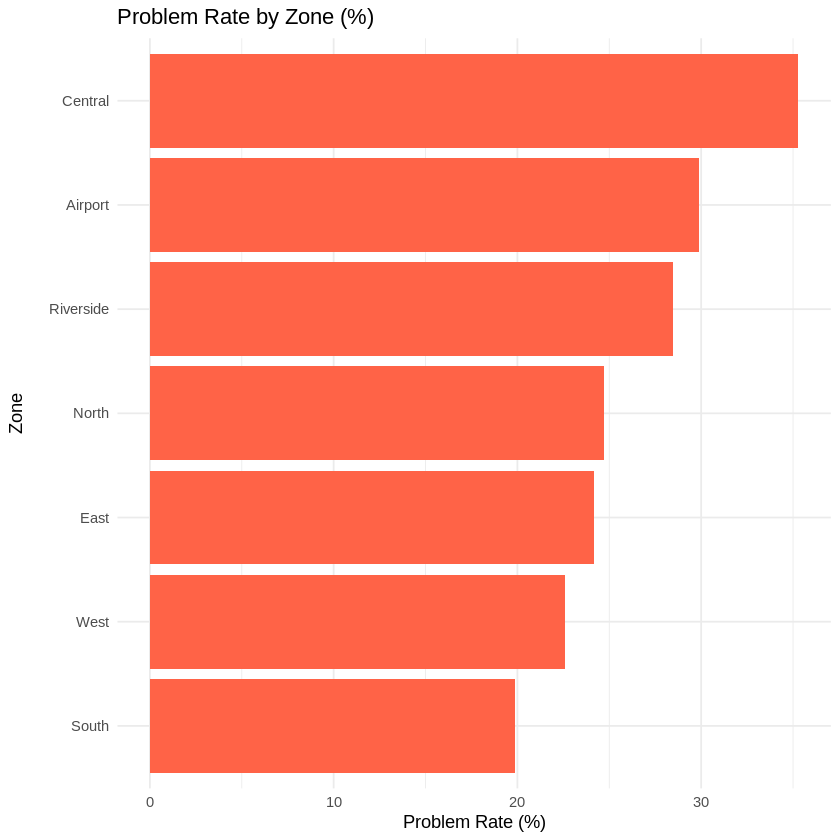

In [8]:
# --------------------------------------------------
# Exploratory Visualizations
# --------------------------------------------------

# 1. Complaint Count by Type
complaint_counts <- complaints_ready %>%
  count(complaint_type) %>%
  arrange(desc(n))

ggplot(complaint_counts, aes(x = reorder(complaint_type, n), y = n)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Number of Complaints by Type",
       x = "Complaint Type",
       y = "Count") +
  theme_minimal()

# 2. Delivery Status Breakdown
ggplot(deliveries_ready, aes(x = delivery_status)) +
  geom_bar(fill = "darkorange") +
  labs(title = "Delivery Status Distribution",
       x = "Status",
       y = "Number of Deliveries") +
  theme_minimal()

# 3. Problem Rate by Zone (Simple Bar)
zone_summary <- orders_ready %>%
  left_join(deliveries_ready, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(
    total = n(),
    problems = sum(delivery_status %in% c("Delayed", "Failed"))
  ) %>%
  mutate(problem_rate = problems / total * 100)

ggplot(zone_summary, aes(x = reorder(pickup_zone, problem_rate), y = problem_rate)) +
  geom_bar(stat = "identity", fill = "tomato") +
  coord_flip() +
  labs(title = "Problem Rate by Zone (%)",
       x = "Zone",
       y = "Problem Rate (%)") +
  theme_minimal()